In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
train_df = pd.read_csv(r"C:\mohab baadawy\dataminig\archive (6)\train_df.csv")
test_df = pd.read_csv(r"C:\mohab baadawy\dataminig\archive (6)\test_df.csv")

In [3]:
train_df.head()

,age,gender,primary_diagnosis,num_procedures,days_in_hospital,comorbidity_score,discharge_to,readmitted
0,69,Male,Heart Disease,1,2,1,Home Health Care,0
1,32,Female,COPD,2,13,2,Rehabilitation Facility,0
2,89,Male,Diabetes,1,7,1,Home,0
3,78,Male,COPD,9,2,2,Skilled Nursing Facility,0
4,38,Male,Diabetes,6,4,4,Rehabilitation Facility,0


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                5000 non-null   int64 
 1   gender             5000 non-null   object
 2   primary_diagnosis  5000 non-null   object
 3   num_procedures     5000 non-null   int64 
 4   days_in_hospital   5000 non-null   int64 
 5   comorbidity_score  5000 non-null   int64 
 6   discharge_to       5000 non-null   object
 7   readmitted         5000 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 312.6+ KB


In [5]:
train_df['primary_diagnosis'].unique()

array(['Heart Disease', 'COPD', 'Diabetes', 'Kidney Disease',
       'Hypertension'], dtype=object)

In [6]:
TARGET = "readmitted"

X = train_df.drop(columns=[TARGET])
y = train_df[TARGET]

X_encoded = pd.get_dummies(X, columns=['gender', 'primary_diagnosis', 'discharge_to'])
test_encoded = pd.get_dummies(test_df, columns=['gender', 'primary_diagnosis', 'discharge_to'])

# Align columns
X_encoded, test_encoded = X_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_encoded)
test_scaled = scaler.transform(test_encoded)

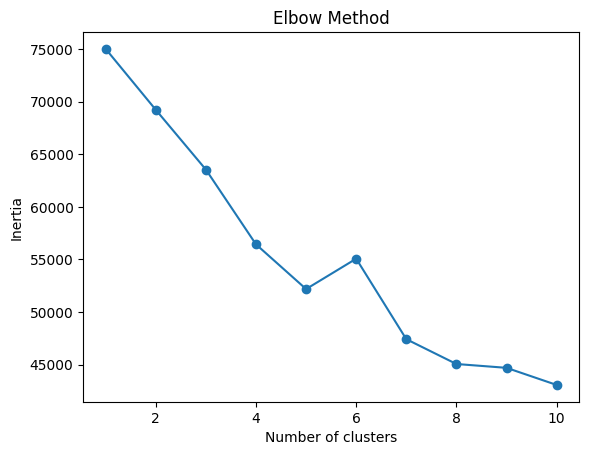

In [8]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [9]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

train_df['cluster'] = clusters

In [10]:
print(train_df['cluster'].value_counts())

train_df.groupby('cluster').mean(numeric_only=True)

cluster
1    2044
2    1995
0     961
Name: count, dtype: int64


,age,num_procedures,days_in_hospital,comorbidity_score,readmitted
cluster,,,,,
0,52.061394,4.366285,7.496358,2.088450,0.182102
1,52.802838,4.528865,7.426614,2.098337,0.198630
2,54.403509,4.437093,7.317794,2.028571,0.179950


In [11]:
pd.crosstab(train_df['cluster'], train_df['primary_diagnosis'], normalize='index')

primary_diagnosis,COPD,Diabetes,Heart Disease,Hypertension,Kidney Disease
cluster,,,,,
0,0.000000,0.000000,1.0,0.000000,0.000000
1,0.069961,0.311644,0.0,0.297456,0.320939
2,0.434085,0.190476,0.0,0.185464,0.189975


In [12]:
for col in ['gender', 'primary_diagnosis', 'discharge_to']:
    print(f"\n=== {col} ===")
    print(train_df.groupby('cluster')[col].value_counts(normalize=True))


=== gender ===
cluster  gender
0        Female    0.516129
         Male      0.483871
1        Female    0.803327
         Male      0.196673
2        Male      0.809023
         Female    0.190977
Name: proportion, dtype: float64

=== primary_diagnosis ===
cluster  primary_diagnosis
0        Heart Disease        1.000000
1        Kidney Disease       0.320939
         Diabetes             0.311644
         Hypertension         0.297456
         COPD                 0.069961
2        COPD                 0.434085
         Diabetes             0.190476
         Kidney Disease       0.189975
         Hypertension         0.185464
Name: proportion, dtype: float64

=== discharge_to ===
cluster  discharge_to            
0        Home Health Care            0.273673
         Rehabilitation Facility     0.254943
         Home                        0.242456
         Skilled Nursing Facility    0.228928
1        Home                        0.460861
         Home Health Care            0.1893

In [13]:
for c in train_df['cluster'].unique():
    print(f"\n========== Cluster {c} ==========")
    
    subset = train_df[train_df['cluster'] == c]
    
    print("Size:", len(subset))
    print("\nAvg values:")
    print(subset.mean(numeric_only=True))
    
    print("\nTop diagnosis:")
    print(subset['primary_diagnosis'].value_counts(normalize=True).head())
    
    print("\nTop discharge:")
    print(subset['discharge_to'].value_counts(normalize=True).head())


========== Cluster 0 ==========
Size: 961

Avg values:
age                  52.061394
num_procedures        4.366285
days_in_hospital      7.496358
comorbidity_score     2.088450
readmitted            0.182102
cluster               0.000000
dtype: float64

Top diagnosis:
primary_diagnosis
Heart Disease    1.0
Name: proportion, dtype: float64

Top discharge:
discharge_to
Home Health Care            0.273673
Rehabilitation Facility     0.254943
Home                        0.242456
Skilled Nursing Facility    0.228928
Name: proportion, dtype: float64

========== Cluster 2 ==========
Size: 1995

Avg values:
age                  54.403509
num_procedures        4.437093
days_in_hospital      7.317794
comorbidity_score     2.028571
readmitted            0.179950
cluster               2.000000
dtype: float64

Top diagnosis:
primary_diagnosis
COPD              0.434085
Diabetes          0.190476
Kidney Disease    0.189975
Hypertension      0.185464
Name: proportion, dtype: float64

Top dischar

In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [15]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [16]:
y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

Accuracy: 0.813

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.98      0.90       826
           1       0.07      0.01      0.01       174

    accuracy                           0.81      1000
   macro avg       0.45      0.49      0.45      1000
weighted avg       0.69      0.81      0.74      1000



In [17]:
cm = confusion_matrix(y_val, y_pred)
print(cm)

[[812  14]
 [173   1]]


In [18]:
importances = model.feature_importances_
feature_names = X_encoded.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_imp.head(10)

age                                0.305012
days_in_hospital                   0.209218
num_procedures                     0.174186
comorbidity_score                  0.118305
primary_diagnosis_Hypertension     0.019298
primary_diagnosis_Diabetes         0.018571
discharge_to_Home                  0.018537
discharge_to_Home Health Care      0.018342
primary_diagnosis_COPD             0.018134
primary_diagnosis_Heart Disease    0.017990
dtype: float64

In [19]:
test_preds = model.predict(test_scaled)

In [20]:
submission = pd.read_csv(r"C:\mohab baadawy\dataminig\archive (6)\sample_submission.csv")

submission[TARGET] = test_preds

submission.to_csv("submission.csv", index=False)

submission.head()

,Patient_ID,readmitted
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
